In [1]:
import eos

In [3]:
eos.Parameters(prefix='mass');

In [2]:
eos.Observables(prefix='B->Kll',name='')

In [4]:
pp = eos.Parameters.Defaults()
oo = eos.Options()
mm = eos.Model.make('WET', pp, oo)

mJpsi = pp['mass::J/psi'].evaluate()
mpsi2S = pp['mass::psi(2S)'].evaluate()
mpi = pp['mass::pi^0'].evaluate()
mD = pp['mass::D^0'].evaluate()

print('mJpsi2 =', mJpsi**2)
print('mpsi2S2 =', mpsi2S**2)

mJpsi2 = 9.590789610000002
mpsi2S2 = 13.58733321


In [3]:
print((mJpsi + mpi)**2)
print((mJpsi + 2*mpi)**2)
print(4*mD**2)

print(mJpsi + mpi, mJpsi + 2*mpi, 2*mD)

10.445027650378242
11.335703163832962
13.910363715599999
3.2318768 3.3668536000000002 3.72966


Generate TEST references

In [2]:
import re

text = r"""
Re{H_+(q2 = 11.000000)}: 564.39593178456471
Im{H_+(q2 = 11.000000)}: 388.05398135569044
"""

for line in text.strip().splitlines():
    if ":" not in line:
        break

    name, value = map(str.strip, line.split(":", 1))

    print(f"\t\t\t\t\tstd::make_pair( {value}, eps ),\t\t// {name}")

					std::make_pair( 564.39593178456471, eps ),		// Re{H_+(q2 = 11.000000)}
					std::make_pair( 388.05398135569044, eps ),		// Im{H_+(q2 = 11.000000)}


# Chebyshev for LHCb Efficiency

In [2]:
import numpy as np
from numpy.polynomial import chebyshev as cheb

import matplotlib.pyplot as plt


$E_{C_A}^{f_0}$

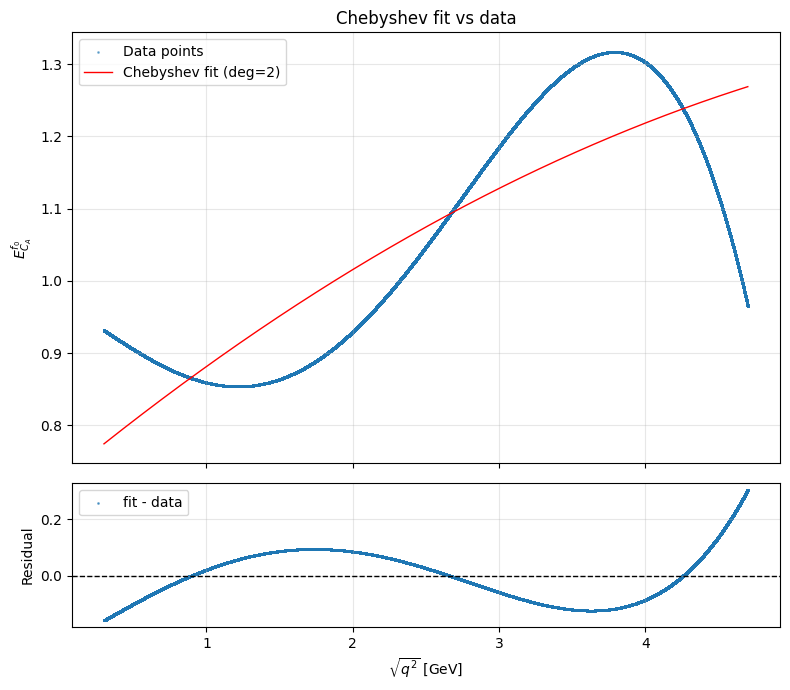

array([ 0.71994263,  0.16694477, -0.00546211])

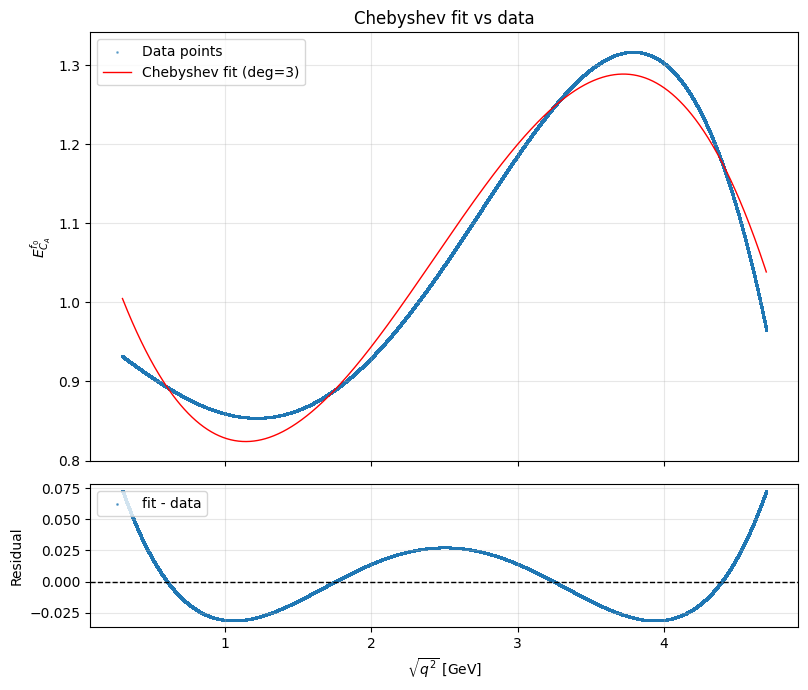

array([ 1.37504414, -0.73046125,  0.19731409, -0.01351841])

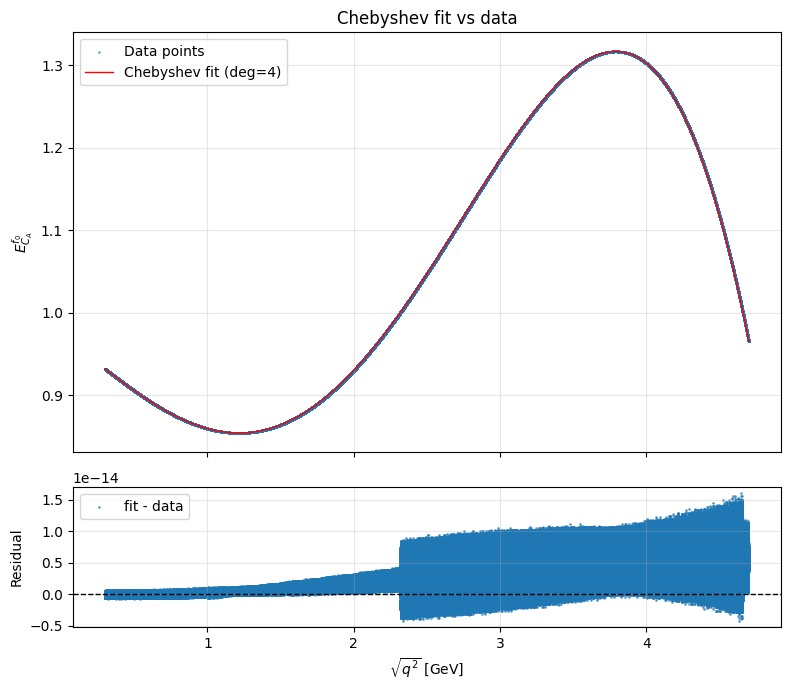

array([ 0.93465892, -0.0566367 , -0.03764524,  0.02068095, -0.00170997])

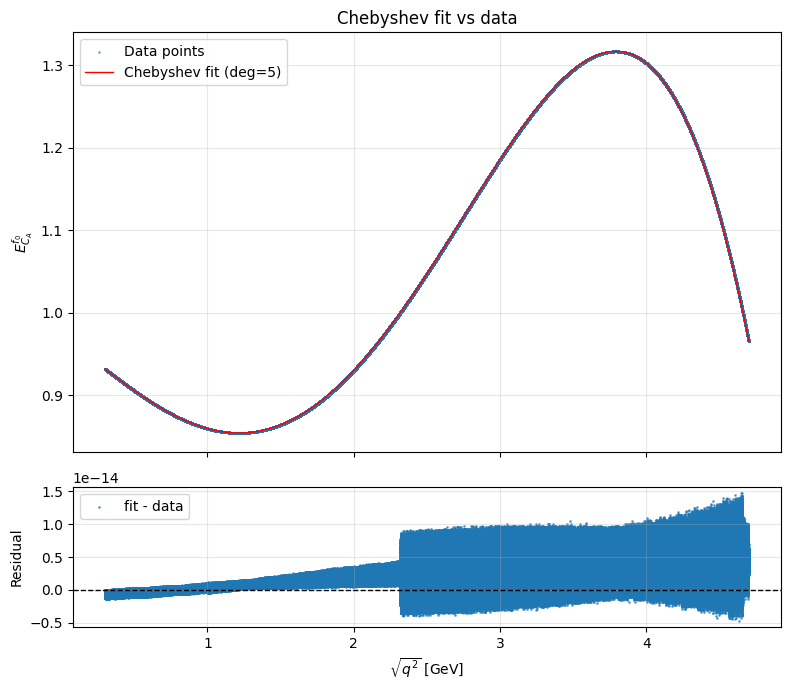

array([ 9.34658925e-01, -5.66366952e-02, -3.76452355e-02,  2.06809478e-02,
       -1.70996804e-03, -1.01076956e-18])

In [3]:
x, y = np.loadtxt(
    "/mt/external/mverzeletti/Repositories/eos/upbsll/py/LHCb-Efficiency.csv",
    delimiter=",",
    skiprows=1,
    unpack=True,
    dtype=np.float64,
    usecols=(0, 1)
)

for deg in [2, 3, 4, 5]:
    coef = cheb.chebfit(x, y, deg=deg)
    y_fit = cheb.chebval(x, coef)
    residuals = y_fit - y

    if(1):
        x_plot = np.linspace(np.min(x), np.max(x), 1000)
        y_plot = cheb.chebval(x_plot, coef)

        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
        )

        ax1.scatter(x, y, s=1, alpha=0.5, label='Data points')
        ax1.plot(x_plot, y_plot, 'r-', linewidth=1.0, label=f'Chebyshev fit (deg={deg})')
        ax1.set_ylabel(r'$E_{C_A}^{f_0}$')
        ax1.set_title('Chebyshev fit vs data')
        ax1.grid(True, alpha=0.3)
        ax1.legend()

        ax2.scatter(x, residuals, s=1, alpha=0.6, color='tab:blue', label='fit - data')
        ax2.axhline(0.0, color='k', linestyle='--', linewidth=1.0)
        ax2.set_xlabel(r'$\sqrt{q^2}$ [GeV]')
        ax2.set_ylabel('Residual')
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='upper left')

        plt.tight_layout()
        plt.show()

    display(coef)

$E_{C_V}^{f_+}$

In [7]:
x, y = np.loadtxt(
    "/mt/external/mverzeletti/Repositories/eos/upbsll/py/LHCb-Efficiency.csv",
    delimiter=",",
    skiprows=1,
    unpack=True,
    dtype=np.float64,
    usecols=(0, 2)
)

for deg in [2, 3, 4, 5]:
    coef = cheb.chebfit(x, y, deg=deg)
    y_fit = cheb.chebval(x, coef)
    residuals = y_fit - y

    if(0):
        x_plot = np.linspace(np.min(x), np.max(x), 1000)
        y_plot = cheb.chebval(x_plot, coef)

        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
        )

        ax1.scatter(x, y, s=1, alpha=0.5, label='Data points')
        ax1.plot(x_plot, y_plot, 'r-', linewidth=1.0, label=f'Chebyshev fit (deg={deg})')
        ax1.set_ylabel(r'$E_{C_A}^{f_0}$')
        ax1.set_title('Chebyshev fit vs data')
        ax1.grid(True, alpha=0.3)
        ax1.legend()

        ax2.scatter(x, residuals, s=1, alpha=0.6, color='tab:blue', label='fit - data')
        ax2.axhline(0.0, color='k', linestyle='--', linewidth=1.0)
        ax2.set_xlabel(r'$\sqrt{q^2}$ [GeV]')
        ax2.set_ylabel('Residual')
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='upper left')

        plt.tight_layout()
        plt.show()

    display(coef)

array([ 0.84361092,  0.1259773 , -0.00535558])

array([ 1.37752765, -0.60542093,  0.15990981, -0.01101769])

array([ 0.73320917,  0.3804378 , -0.18385431,  0.03901868, -0.00250182])

array([ 7.33209169e-01,  3.80437802e-01, -1.83854308e-01,  3.90186834e-02,
       -2.50181878e-03, -1.25346093e-18])

$E_{C_A}^{f_+}$

In [8]:
x, y = np.loadtxt(
    "/mt/external/mverzeletti/Repositories/eos/upbsll/py/LHCb-Efficiency.csv",
    delimiter=",",
    skiprows=1,
    unpack=True,
    dtype=np.float64,
    usecols=(0, 3)
)

for deg in [2, 3, 4, 5]:
    coef = cheb.chebfit(x, y, deg=deg)
    y_fit = cheb.chebval(x, coef)
    residuals = y_fit - y

    if(0):
        x_plot = np.linspace(np.min(x), np.max(x), 1000)
        y_plot = cheb.chebval(x_plot, coef)

        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
        )

        ax1.scatter(x, y, s=1, alpha=0.5, label='Data points')
        ax1.plot(x_plot, y_plot, 'r-', linewidth=1.0, label=f'Chebyshev fit (deg={deg})')
        ax1.set_ylabel(r'$E_{C_A}^{f_0}$')
        ax1.set_title('Chebyshev fit vs data')
        ax1.grid(True, alpha=0.3)
        ax1.legend()

        ax2.scatter(x, residuals, s=1, alpha=0.6, color='tab:blue', label='fit - data')
        ax2.axhline(0.0, color='k', linestyle='--', linewidth=1.0)
        ax2.set_xlabel(r'$\sqrt{q^2}$ [GeV]')
        ax2.set_ylabel('Residual')
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='upper left')

        plt.tight_layout()
        plt.show()

    display(coef)

array([ 0.87167455,  0.10782208, -0.00393692])

array([ 1.42312851, -0.64759993,  0.16675683, -0.01137958])

array([ 0.79740096,  0.3098132 , -0.16708844,  0.03721306, -0.00242963])

array([ 7.97400958e-01,  3.09813203e-01, -1.67088441e-01,  3.72130612e-02,
       -2.42963223e-03, -1.42414498e-18])

# LHCb: Resolution

In [30]:
import numpy as np

q2grid = np.loadtxt(
    "/mt/external/mverzeletti/Repositories/eos/upbsll/py/LHCb-resolution.csv",
    delimiter=",",
    skiprows=1,
    unpack=True,
    dtype=np.float64,
    usecols=(0)
)

resolution2 = np.loadtxt(
    "/mt/external/mverzeletti/Repositories/eos/upbsll/py/LHCb-resolution.csv",
    delimiter=",",
    skiprows=1,
    unpack=True,
    dtype=np.float64,
    usecols=(2)
)

display(resolution2)

indices = np.linspace(0, len(q2grid) - 1, 50, dtype=int)

display(q2grid[indices]**2)
display(resolution2[indices])

resolution2=resolution2[indices]
display(resolution2)

array([9.48111701e-13, 9.48243623e-13, 9.48375565e-13, ...,
       5.82823471e-15, 5.82717054e-15, 5.82610657e-15], shape=(159092,))

array([3.24000396, 3.29162467, 3.34366945, 3.39612245, 3.44898368,
       3.50223666, 3.55591422, 3.61      , 3.66449401, 3.71937927,
       3.7746896 , 3.83040816, 3.88653495, 3.94305249, 3.9999956 ,
       4.05734694, 4.1151065 , 4.17325632, 4.23183221, 4.29081633,
       4.35020867, 4.40999076, 4.47019943, 4.53081633, 4.59184145,
       4.65325581, 4.71509726, 4.77734694, 4.84000484, 4.90305148,
       4.96652571, 5.03040816, 5.09469884, 5.15937776, 5.22448477,
       5.29      , 5.35592346, 5.42223465, 5.48897444, 5.55612245,
       5.62367869, 5.69162216, 5.75999472, 5.82877551, 5.89796453,
       5.96754027, 6.03754561, 6.10795918, 6.17878098, 6.250011  ])

array([9.48111701e-13, 1.50133312e-12, 2.41803090e-12, 3.96559681e-12,
       6.63190197e-12, 1.13259559e-11, 1.97947067e-11, 3.54718272e-11,
       6.53276420e-11, 1.23956857e-10, 2.43178908e-10, 4.94938384e-10,
       1.04951894e-09, 2.32978799e-09, 5.44945284e-09, 1.35255222e-08,
       3.59409234e-08, 1.03353127e-07, 3.26382659e-07, 1.15219150e-06,
       4.65706073e-06, 2.22545648e-05, 1.31887395e-04, 1.23229866e-03,
       3.08228485e-02, 3.07133271e-02, 1.02476609e-03, 8.05584107e-05,
       1.02359680e-05, 1.61268418e-06, 3.01935860e-07, 6.52521394e-08,
       1.59130379e-08, 4.30409283e-09, 1.27211197e-09, 4.06376076e-10,
       1.39008401e-10, 5.05398716e-11, 1.93916984e-11, 7.81149443e-12,
       3.28809728e-12, 1.44076772e-12, 6.54535645e-13, 3.07426223e-13,
       1.48882733e-13, 7.41821659e-14, 3.79316052e-14, 1.98712445e-14,
       1.06472468e-14, 5.82610657e-15])

array([9.48111701e-13, 1.50133312e-12, 2.41803090e-12, 3.96559681e-12,
       6.63190197e-12, 1.13259559e-11, 1.97947067e-11, 3.54718272e-11,
       6.53276420e-11, 1.23956857e-10, 2.43178908e-10, 4.94938384e-10,
       1.04951894e-09, 2.32978799e-09, 5.44945284e-09, 1.35255222e-08,
       3.59409234e-08, 1.03353127e-07, 3.26382659e-07, 1.15219150e-06,
       4.65706073e-06, 2.22545648e-05, 1.31887395e-04, 1.23229866e-03,
       3.08228485e-02, 3.07133271e-02, 1.02476609e-03, 8.05584107e-05,
       1.02359680e-05, 1.61268418e-06, 3.01935860e-07, 6.52521394e-08,
       1.59130379e-08, 4.30409283e-09, 1.27211197e-09, 4.06376076e-10,
       1.39008401e-10, 5.05398716e-11, 1.93916984e-11, 7.81149443e-12,
       3.28809728e-12, 1.44076772e-12, 6.54535645e-13, 3.07426223e-13,
       1.48882733e-13, 7.41821659e-14, 3.79316052e-14, 1.98712445e-14,
       1.06472468e-14, 5.82610657e-15])

In [26]:
checkspacing=[(q2grid[indices[i]]-q2grid[indices[i-1]])*1000 for i in range(1, len(indices))]
for s in checkspacing:
    print(s,"MeV")

14.28241428241006 MeV
14.286814286819993 MeV
14.286814286810001 MeV
14.286814286819993 MeV
14.282414282409839 MeV
14.286814286819993 MeV
14.286814286810001 MeV
14.286814286810001 MeV
14.282414282420053 MeV
14.286814286810001 MeV
14.286814286819993 MeV
14.286814286810001 MeV
14.282414282420053 MeV
14.286814286810001 MeV
14.28681428680978 MeV
14.286814286819993 MeV
14.282414282410283 MeV
14.286814286819993 MeV
14.28681428680978 MeV
14.286814286819993 MeV
14.282414282410283 MeV
14.28681428680978 MeV
14.286814286819993 MeV
14.286814286810223 MeV
14.282414282420053 MeV
14.28681428680978 MeV
14.286814286819993 MeV
14.286814286810223 MeV
14.282414282409839 MeV
14.286814286819993 MeV
14.286814286810223 MeV
14.286814286819993 MeV
14.282414282409839 MeV
14.286814286819993 MeV
14.28681428680978 MeV
14.286814286810223 MeV
14.282414282420053 MeV
14.28681428680978 MeV
14.286814286819993 MeV
14.286814286810223 MeV
14.282414282420053 MeV
14.28681428680978 MeV
14.286814286810223 MeV
14.286814286819993 

In [32]:
print(1.8**2, 2.51**2)

3.24 6.300099999999999


## Resolution fits

In [6]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

x = np.loadtxt(
    "/mt/external/mverzeletti/Repositories/eos/upbsll/py/LHCb-resolution.csv",
    delimiter=",",
    skiprows=1,
    unpack=True,
    dtype=np.float64,
    usecols=(0)
)

y = np.loadtxt(
    "/mt/external/mverzeletti/Repositories/eos/upbsll/py/LHCb-resolution.csv",
    delimiter=",",
    skiprows=1,
    unpack=True,
    dtype=np.float64,
    usecols=(2)
)

def model(x, A1, A2, A3, mu, sigma1, sigma2, n, a):
    x = np.asarray(x)
    t = (x - mu) / sigma2
    A = (n/a)**n * np.exp(-a**2/2)
    B = n/a - a

    core = A1 * np.exp( -(x - mu)**2 / (2.0 * sigma1**2) )

    y_model = np.empty_like(x)

    center = (t > -a) & (t < a)
    left = (t <= -a)
    right = (t >= a)

    y_model[center] = core[center] + A2 * np.exp( -(x[center] - mu)**2 / (2*sigma2**2) )
    y_model[left] = core[left] + A3 * A * (B - t[left])**(-n)
    y_model[right] = core[right] + A3 * A * (B + t[right])**(-n)

    return y_model

/tmp/ipykernel_779274/478478199.py:26: RuntimeWarning: invalid value encountered in scalar power
  A = (n/a)**n * np.exp(-a**2/2)
/tmp/ipykernel_779274/478478199.py:38: RuntimeWarning: overflow encountered in power
  y_model[left] = core[left] + A3 * A * (B - t[left])**(-n)
/tmp/ipykernel_779274/478478199.py:38: RuntimeWarning: invalid value encountered in power
  y_model[left] = core[left] + A3 * A * (B - t[left])**(-n)
/tmp/ipykernel_779274/478478199.py:39: RuntimeWarning: overflow encountered in power
  y_model[right] = core[right] + A3 * A * (B + t[right])**(-n)
/tmp/ipykernel_779274/478478199.py:39: RuntimeWarning: invalid value encountered in power
  y_model[right] = core[right] + A3 * A * (B + t[right])**(-n)


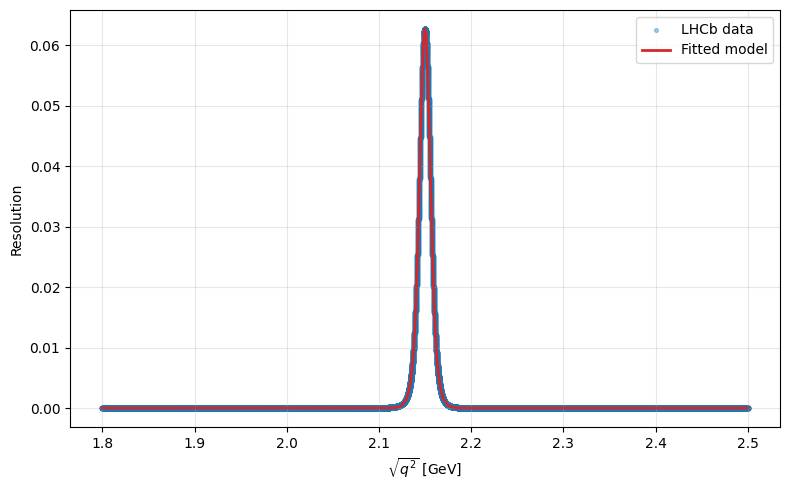

[ 0.01302544  0.04973772 -0.01313848  2.14998302  0.00975637  0.005439
  5.04188018  3.45474586]


In [7]:
p0 = [0.1,0.1,0.1,2.15,0.02,0.02,1,1]
p1= [ 0.01302544,  0.04973772, -0.01313848,  2.14998302,  0.00975637 , 0.005439,  5.04188018 , 3.45474586]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p1
)

m_grid = np.linspace(np.min(x), np.max(x), 1200)
y_fit = model(m_grid, *popt)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=8, alpha=0.35, label='LHCb data')
plt.plot(m_grid, y_fit, color='tab:red', linewidth=2.0, label='Fitted model')
plt.xlabel(r'$\sqrt{q^2}$ [GeV]')
plt.ylabel('Resolution')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(popt)

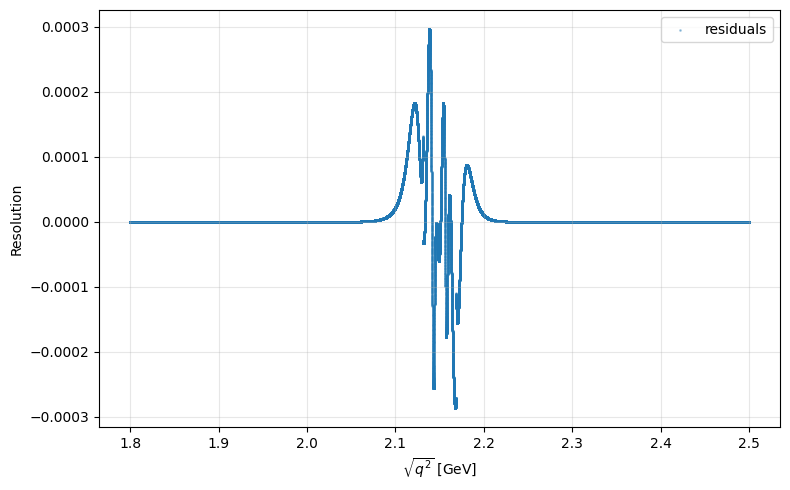

In [8]:
yfit = [model(xi, *popt) for xi in x]
residuals = y - yfit
plt.figure(figsize=(8, 5))
plt.scatter(x, residuals, s=1, alpha=0.35, label='residuals')
plt.xlabel(r'$\sqrt{q^2}$ [GeV]')
plt.ylabel('Resolution')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
q2_min = 1.8**2
q2_max = 2.51**2
ngridpoints = 100
gridstep = (q2_max - q2_min) / (ngridpoints - 1)

q2grid = [q2_min + i * gridstep for i in range(ngridpoints)]
print(q2grid[0]-q2_min, q2grid[-1]-q2_max)

0.0 0.0


## q2 data filtering

In [12]:
import numpy as np

d = np.loadtxt(
    "/mt/external/mverzeletti/Repositories/eos/upbsll/py/LHCb-data.csv",
    delimiter=",",
    skiprows=1,
    unpack=True,
    dtype=np.float64,
    usecols=(0)
)

d = (d/1000.0)**2

In [18]:
d_g5000 = d[d>5.0]
display(d_g5000)

d_l3500 = d[d<3.5]
display(d_l3500)

d_selected = d[(d>q2_min) & (d<q2_max)]
display(d_selected)

array([9.64289511, 9.58672478, 9.52661867, ..., 9.6104813 , 9.61289039,
       9.52377517], shape=(3358128,))

array([2.68475469, 3.06776041, 0.49219517, ..., 1.44237627, 3.34288696,
       1.33058737], shape=(4192,))

array([4.01091233, 6.28105955, 6.07301443, ..., 4.03391607, 3.34288696,
       4.53718684], shape=(3445,))